### Schema v2 field map (read_export)

Each row's `data` column is the `sample` array; `data[0]` is the event. v2 keys:
- `tag`: `MEASUREMENT` | `STATUS` | `DEVICE_INFO` (filter on this, not `sensor`).
- `channel`: `uart_<n>` (AMBIT port; old `AMBIT_1` = `uart_0`), or null (onboard).
- `cmd_raw`: full device command (`arrun ...`, `get_par`, `get_temp`, `device.bme280`).
- `device`: AMBIT name (from `DEVICE_INFO`/calibration), or `ambit`/null.
- `metadata`: `segments` (+ `gains`/`currents`/`cal_version`) for AMBIT runs.
- nested `data.*`: the quantities (`data.s_fluo`, `data.sun`, `data.spec`, ...).

`DEVICE_INFO` events (once per connection) carry the full calibration; join to
measurements on `device_id` + `metadata.cal_version`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 
import glob
import json     

In [2]:
import pandas as pd, glob

for file in glob.glob('*.json'):
    df = pd.read_json(file, lines=True)
df = df.sort_values(by='timestamp', ascending=True)
df.head()

,id,device_id,device_name,timestamp,measurement_time_utc,date,data,processed_timestamp,annotations
0,1299333926,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:01:59+00:00,2001-01-01T00:01:59.000Z,2001-01-01,"[{'data': {'env': [22.42], 'leaf': [140, 343, ...",2026-06-09T12:45:56.756Z,[]
1,1344848666,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:02:00+00:00,2001-01-01T00:02:00.000Z,2001-01-01,"[{'data': {'env': [22.08], 'leaf': [144, 342, ...",2026-06-09T12:45:56.756Z,[]
2,1599866163,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:02:00+00:00,2001-01-01T00:02:00.000Z,2001-01-01,"[{'data': {'env': [21.99], 'leaf': [878, 656, ...",2026-06-09T12:45:56.756Z,[]
3,186516016,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:02:00+00:00,2001-01-01T00:02:00.000Z,2001-01-01,"[{'data': {'env': [21.87], 'leaf': [41, 287, 2...",2026-06-09T12:45:56.756Z,[]
4,1459088716,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:02:00+00:00,2001-01-01T00:02:00.000Z,2001-01-01,"[{'data': {'env': [22.35], 'leaf': [357, 361, ...",2026-06-09T12:45:56.756Z,[]


In [ ]:
# v2 delivery is at-least-once: the cloud pipeline keeps QoS-1 redeliveries as
# distinct rows by design (the silver `id` hashes the Kinesis sequence number).
# Dedup here on (device_id, measure_id) — measure_id is unique per device — and
# keep the earliest copy. measure_id lives in the sample object (data[0]).
def _measure_id(s):
    return s[0].get('measure_id') if isinstance(s, list) and s else None

df['_measure_id'] = df['data'].apply(_measure_id)
_keys = ['device_id', '_measure_id'] if 'device_id' in df.columns else ['_measure_id']
_before = len(df)
df = (df.sort_values('timestamp')
        .drop_duplicates(subset=_keys, keep='first')
        .reset_index(drop=True))
print(f'dedup on {_keys}: {_before} -> {len(df)} rows '
      f'({_before - len(df)} duplicate redeliveries dropped)')


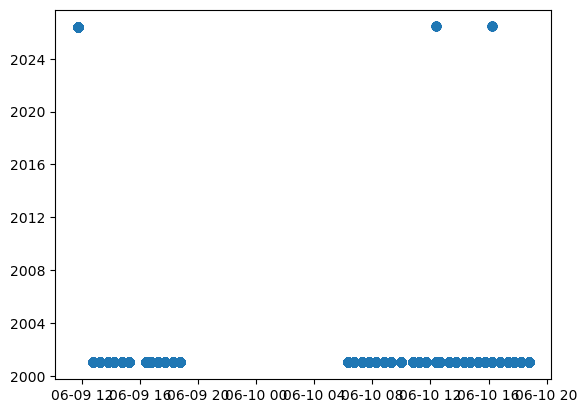

In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df["processed_timestamp"] = pd.to_datetime(df["processed_timestamp"])

tdf = df[df["processed_timestamp"] > "2026-06-09 11:00:00"]
plt.scatter(tdf["processed_timestamp"], tdf["timestamp"])

In [4]:
results = []
for row in df.itertuples():
    data = row.data
    # v2: STATUS heartbeat events are tagged; their data has battery_v/system_v/...
    if data[0].get("tag") == "STATUS":
        results.append(row)

df_bat= pd.DataFrame(results)
inner = pd.json_normalize(df_bat['data'].str[0])   # -> data.s_fluo, channel, cmd_raw, tag, measure_id, ...
inner.index = df_bat.index
df_bat = pd.concat([df_bat.drop(columns='data'), inner], axis=1)
df_bat.head()

,Index,id,device_id,device_name,timestamp,measurement_time_utc,date,processed_timestamp,annotations,device,...,data.charge_ma,data.charge_status,data.db_online,data.input_ma,data.input_present,data.input_v,data.provisioned,data.publish_gate,data.system_v,data.wifi
0,182,441751963,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:05:02+00:00,2001-01-01T00:05:02.000Z,2001-01-01,2026-06-09 12:45:56.756000+00:00,[],None,...,0,0,True,239,True,5.04,True,True,4.04,True
1,183,99762516,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:05:03+00:00,2001-01-01T00:05:03.000Z,2001-01-01,2026-06-09 13:14:14.576000+00:00,[],None,...,490,2,True,532,True,6.84,True,True,3.98,True
2,312,1391434272,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:10:03+00:00,2001-01-01T00:10:03.000Z,2001-01-01,2026-06-09 13:14:14.576000+00:00,[],None,...,542,2,True,518,True,7.02,True,True,3.98,True
3,421,802135888,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:15:03+00:00,2001-01-01T00:15:03.000Z,2001-01-01,2026-06-09 13:46:50.166000+00:00,[],None,...,0,2,True,292,True,4.26,True,True,3.94,True
4,534,1727143778,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:20:03+00:00,2001-01-01T00:20:03.000Z,2001-01-01,2026-06-09 13:46:50.166000+00:00,[],None,...,0,2,True,279,True,4.20,True,True,3.94,True


<Axes: xlabel='measurement_time_utc'>

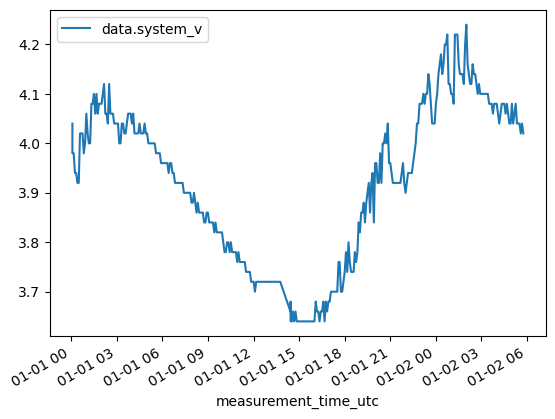

In [8]:

df_bat["measurement_time_utc"] = pd.to_datetime(df_bat["measurement_time_utc"])
df_bat = df_bat[df_bat["measurement_time_utc"] < "2022-06-09 11:00:00"]
df_bat.plot(x="measurement_time_utc", y="data.system_v")

<Axes: xlabel='measurement_time_utc'>

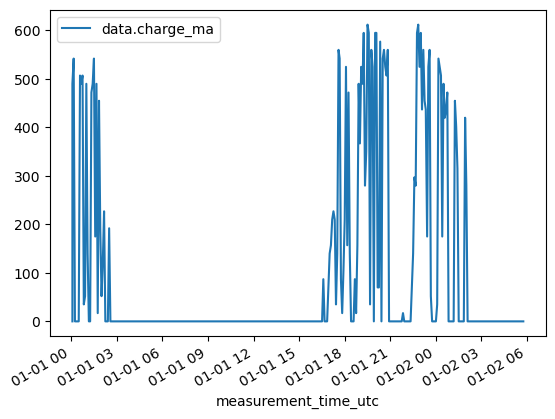

In [9]:
df_bat.plot(x="measurement_time_utc", y="data.charge_ma")

<Axes: xlabel='measurement_time_utc'>

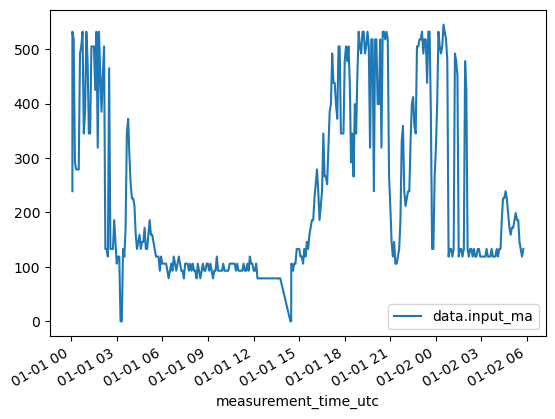

In [10]:
df_bat.plot(x="measurement_time_utc", y="data.input_ma")

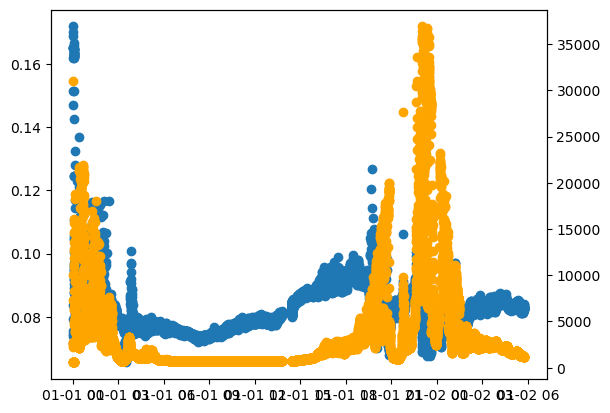

In [28]:
results = []
for row in df.itertuples():
    data = row.data[0]
    if data.get("tag")=="MEASUREMENT" and data.get("channel")=="uart_0":
        results.append(row)

dfamb = pd.DataFrame(results)
inner = pd.json_normalize(dfamb['data'].str[0])   # -> data.s_fluo, channel, cmd_raw, tag, measure_id, ...
inner.index = dfamb.index
dfamb = pd.concat([dfamb.drop(columns='data'), inner], axis=1)
dfamb.head()

dfamb = dfamb[dfamb["data.s_fluo"].str.len() == 4]
dfamb["processed_timestamp"] = pd.to_datetime(dfamb["processed_timestamp"])
dfamb["measurement_time_utc"] = pd.to_datetime(dfamb["measurement_time_utc"])
dfamb = dfamb[dfamb["measurement_time_utc"] < "2022-06-10 10:00:00"]

dfamb["fluo_ss"] = [np.mean(np.array(x)/np.array(y)) for x, y in zip(dfamb["data.s_fluo"],dfamb["data.r_fluo"])]
dfamb["sun"] = [np.mean(np.array(x)) for x in dfamb["data.sun"]]


fig, ax = plt.subplots()
ax.scatter(dfamb["measurement_time_utc"], dfamb["fluo_ss"], label="s_fluo_0")
ax2 = ax.twinx()
ax2.scatter(dfamb["measurement_time_utc"], dfamb["sun"], label="sun", color="orange")


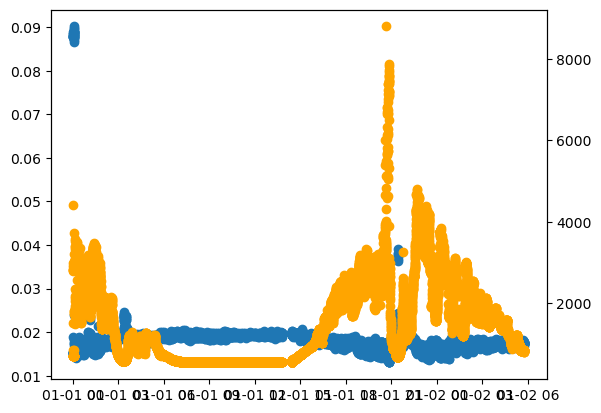

In [25]:
results = []
for row in df.itertuples():
    data = row.data[0]
    if data.get("tag")=="MEASUREMENT" and data.get("channel")=="uart_1":
        results.append(row)

dfamb = pd.DataFrame(results)
inner = pd.json_normalize(dfamb['data'].str[0])   # -> data.s_fluo, channel, cmd_raw, tag, measure_id, ...
inner.index = dfamb.index
dfamb = pd.concat([dfamb.drop(columns='data'), inner], axis=1)
dfamb.head()

dfamb = dfamb[dfamb["data.s_fluo"].str.len() == 4]
dfamb["processed_timestamp"] = pd.to_datetime(dfamb["processed_timestamp"])
dfamb["measurement_time_utc"] = pd.to_datetime(dfamb["measurement_time_utc"])
dfamb = dfamb[dfamb["measurement_time_utc"] < "2022-06-10 10:00:00"]

dfamb["fluo_ss"] = [np.mean(np.array(x)/np.array(y)) for x, y in zip(dfamb["data.s_fluo"],dfamb["data.r_fluo"])]
dfamb["sun"] = [np.mean(np.array(x)) for x in dfamb["data.sun"]]


fig, ax = plt.subplots()
ax.scatter(dfamb["measurement_time_utc"], dfamb["fluo_ss"], label="s_fluo_0")
ax2 = ax.twinx()
ax2.scatter(dfamb["measurement_time_utc"], dfamb["sun"], label="sun", color="orange")


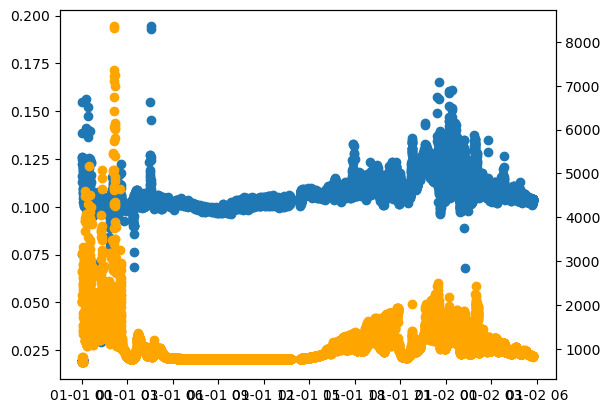

In [26]:
results = []
for row in df.itertuples():
    data = row.data[0]
    if data.get("tag")=="MEASUREMENT" and data.get("channel")=="uart_2":
        results.append(row)

dfamb = pd.DataFrame(results)
inner = pd.json_normalize(dfamb['data'].str[0])   # -> data.s_fluo, channel, cmd_raw, tag, measure_id, ...
inner.index = dfamb.index
dfamb = pd.concat([dfamb.drop(columns='data'), inner], axis=1)
dfamb.head()

dfamb = dfamb[dfamb["data.s_fluo"].str.len() == 4]
dfamb["processed_timestamp"] = pd.to_datetime(dfamb["processed_timestamp"])
dfamb["measurement_time_utc"] = pd.to_datetime(dfamb["measurement_time_utc"])
dfamb = dfamb[dfamb["measurement_time_utc"] < "2022-06-10 10:00:00"]

dfamb["fluo_ss"] = [np.mean(np.array(x)/np.array(y)) for x, y in zip(dfamb["data.s_fluo"],dfamb["data.r_fluo"])]
dfamb["sun"] = [np.mean(np.array(x)) for x in dfamb["data.sun"]]


fig, ax = plt.subplots()
ax.scatter(dfamb["measurement_time_utc"], dfamb["fluo_ss"], label="s_fluo_0")
ax2 = ax.twinx()
ax2.scatter(dfamb["measurement_time_utc"], dfamb["sun"], label="sun", color="orange")


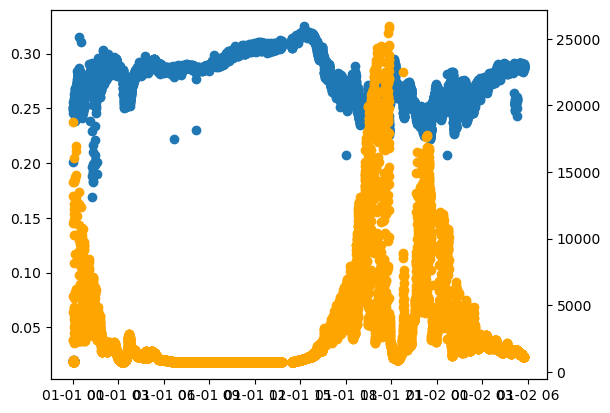

In [27]:
results = []
for row in df.itertuples():
    data = row.data[0]
    if data.get("tag")=="MEASUREMENT" and data.get("channel")=="uart_3":
        results.append(row)

dfamb = pd.DataFrame(results)
inner = pd.json_normalize(dfamb['data'].str[0])   # -> data.s_fluo, channel, cmd_raw, tag, measure_id, ...
inner.index = dfamb.index
dfamb = pd.concat([dfamb.drop(columns='data'), inner], axis=1)
dfamb.head()

dfamb = dfamb[dfamb["data.s_fluo"].str.len() == 4]
dfamb["processed_timestamp"] = pd.to_datetime(dfamb["processed_timestamp"])
dfamb["measurement_time_utc"] = pd.to_datetime(dfamb["measurement_time_utc"])
dfamb = dfamb[dfamb["measurement_time_utc"] < "2022-06-10 10:00:00"]

dfamb["fluo_ss"] = [np.mean(np.array(x)/np.array(y)) for x, y in zip(dfamb["data.s_fluo"],dfamb["data.r_fluo"])]
dfamb["sun"] = [np.mean(np.array(x)) for x in dfamb["data.sun"]]


fig, ax = plt.subplots()
ax.scatter(dfamb["measurement_time_utc"], dfamb["fluo_ss"], label="s_fluo_0")
ax2 = ax.twinx()
ax2.scatter(dfamb["measurement_time_utc"], dfamb["sun"], label="sun", color="orange")


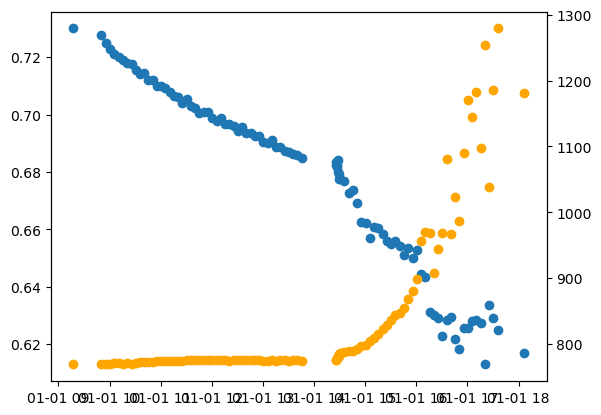

In [34]:
results = []
for row in df.itertuples():
    data = row.data[0]
    if data.get("tag")=="MEASUREMENT" and data.get("channel")=="uart_2":
        results.append(row)

dfamb = pd.DataFrame(results)
inner = pd.json_normalize(dfamb['data'].str[0])   # -> data.s_fluo, channel, cmd_raw, tag, measure_id, ...
inner.index = dfamb.index
dfamb = pd.concat([dfamb.drop(columns='data'), inner], axis=1)
dfamb.head()

dfamb = dfamb[dfamb["data.s_fluo"].str.len() > 4]
dfamb["processed_timestamp"] = pd.to_datetime(dfamb["processed_timestamp"])
dfamb["measurement_time_utc"] = pd.to_datetime(dfamb["measurement_time_utc"])
dfamb = dfamb[dfamb["measurement_time_utc"] < "2022-06-10 10:00:00"]

dfamb["fluo"] = [np.array(x)/np.array(y) for x, y in zip(dfamb["data.s_fluo"],dfamb["data.r_fluo"])]
dfamb["fo"]= [np.mean(x[30:40]) for x in dfamb["fluo"]]
dfamb["fm"]= [np.mean(x[40+50:40+70]) for x in dfamb["fluo"]]
dfamb["phi2"] = (dfamb["fm"]-dfamb["fo"])/dfamb["fm"]
dfamb["sun"] = [np.mean(np.array(x)) for x in dfamb["data.sun"]]


fig, ax = plt.subplots()
ax.scatter(dfamb["measurement_time_utc"], dfamb["phi2"], label="s_fluo_0")
ax2 = ax.twinx()
ax2.scatter(dfamb["measurement_time_utc"], dfamb["sun"], label="sun", color="orange")


In [30]:
dfamb

,Index,id,device_id,device_name,timestamp,measurement_time_utc,date,processed_timestamp,annotations,device,...,metadata,data.par,data.spec,metadata.cal_version,metadata.cmd,metadata.deviceID,metadata.fw_version,metadata.schema_version,metadata.sensor_ch,sun
3197,12895,250373634,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 09:17:28+00:00,2001-01-01 09:17:28+00:00,2001-01-01,2026-06-10 06:19:31.791000+00:00,[],ambit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,717.050000
3385,13669,269183302,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 09:50:36+00:00,2001-01-01 09:50:36+00:00,2001-01-01,2026-06-10 06:19:31.791000+00:00,[],ambit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,718.211111
3413,13802,311399913,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 09:55:36+00:00,2001-01-01 09:55:36+00:00,2001-01-01,2026-06-10 06:19:31.791000+00:00,[],ambit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,717.622222
3441,13935,571497733,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 10:00:35+00:00,2001-01-01 10:00:35+00:00,2001-01-01,2026-06-10 06:19:31.791000+00:00,[],ambit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,717.227778
3468,14064,1960581256,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 10:05:36+00:00,2001-01-01 10:05:36+00:00,2001-01-01,2026-06-10 06:19:31.791000+00:00,[],ambit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,717.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5781,25143,1138153042,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 17:20:36+00:00,2001-01-01 17:20:36+00:00,2001-01-01,2026-06-10 06:44:16.663000+00:00,[],ambit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4227.805556
5808,25272,1008929814,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 17:25:36+00:00,2001-01-01 17:25:36+00:00,2001-01-01,2026-06-10 06:44:16.663000+00:00,[],ambit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3063.144444
5835,25401,774510357,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 17:30:35+00:00,2001-01-01 17:30:35+00:00,2001-01-01,2026-06-10 06:44:16.663000+00:00,[],ambit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3742.255556
5863,25534,828877902,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 17:35:35+00:00,2001-01-01 17:35:35+00:00,2001-01-01,2026-06-10 06:44:16.663000+00:00,[],ambit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4785.211111
